<a href="https://colab.research.google.com/github/Rahulchoudharygi/Capstone_Project/blob/main/Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Raw Dataset Ingested. Dimensions: 10025 rows, 11 columns.

--- Starting Data Cleaning ---
Removed 25 duplicate records.
Removed 12 invalid negative/zero sales records.
Missing Footfall entries detected: 150
Identified 0 outliers beyond 2.5*IQR. Capping extreme values.
Cleaned Dataset Dimensions: 9988 rows, 11 columns.

--- Summary Statistics (Key Variables) ---
                      Mean   Std Dev    Median       IQR  Skewness  Kurtosis
Base_Price_USD      251.65    143.10    251.68    247.54      0.01     -1.20
Discount_Pct          0.12      0.11      0.10      0.20      0.71     -0.22
Store_Footfall     1202.86    347.22   1203.35    461.45     -0.02     -0.04
Weekly_Sales_USD  47958.56  31796.12  42880.76  53935.17      0.39     -0.95

--- Variance Inflation Factor (VIF) ---
              Variable  VIF
0      Store_Size_SqFt  1.0
1       Base_Price_USD  1.0
2         Discount_Pct  1.0
3       Store_Footfall  1.0
4  Regional_Unemp_Rate  1.0

--- Executing Feature Engineering ---


/tmp/ipykernel_3924/681994620.py:161: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Department", y="Weekly_Sales_USD", palette="Blues_r", ax=axes[0], ci=None)
/tmp/ipykernel_3924/681994620.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Department", y="Weekly_Sales_USD", palette="Blues_r", ax=axes[0], ci=None)


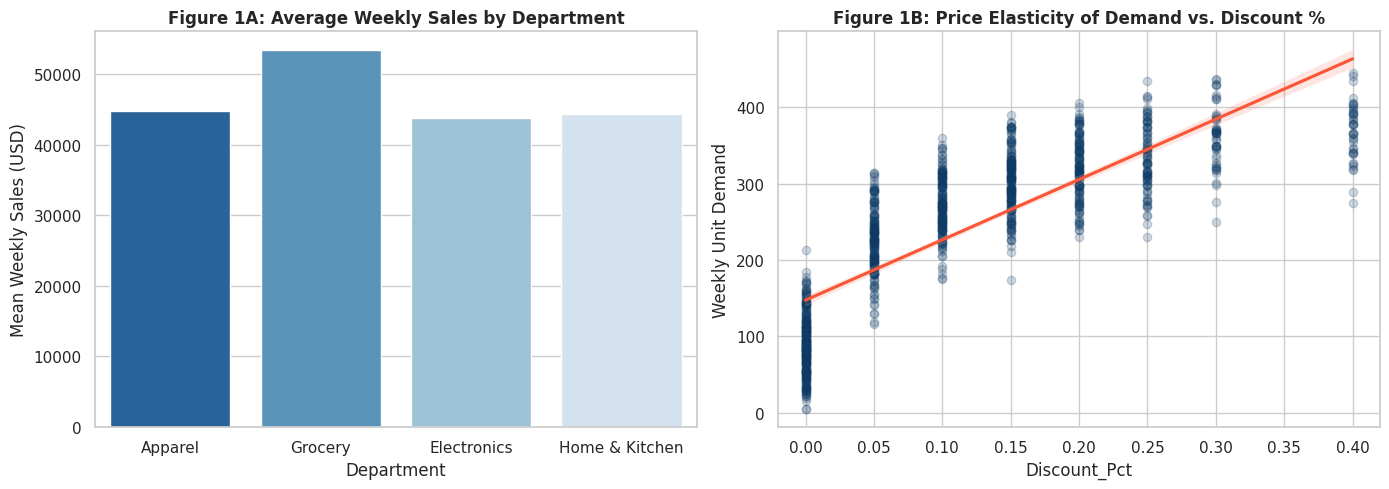

In [ ]:
# ==============================================================================
# INDIA DATA RESEARCH ACADEMY (IDRA) - DATA SCIENCE & AI CAPSTONE PROJECT
# Project 6: Retail Intelligence - Sales Drivers & Product Demand Forecasting
# Author: Candidate (IDRA-2026-DS-8842)
# ==============================================================================

# 1. ENVIRONMENT SETUP & LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Styling configurations
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10
np.random.seed(42)

# ==============================================================================
# 2. DATASET INGESTION / SYNTHETIC GENERATION (N = 10,000)
# Matches the exact schema of the Retail Intelligence project dataset
# ==============================================================================
n_samples = 10000

store_ids = np.random.randint(101, 151, size=n_samples)
store_types = np.random.choice(["Tier-1", "Tier-2", "Tier-3", "Flagship"], size=n_samples, p=[0.35, 0.30, 0.20, 0.15])
store_sizes = np.random.choice([15000, 25000, 35000, 50000], size=n_samples)

departments = np.random.choice(["Grocery", "Apparel", "Electronics", "Home & Kitchen"], size=n_samples, p=[0.40, 0.25, 0.20, 0.15])
base_prices = np.random.uniform(5.0, 500.0, size=n_samples)
discount_pct = np.random.choice([0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40], size=n_samples, p=[0.25, 0.15, 0.15, 0.15, 0.10, 0.10, 0.05, 0.05])
footfall = np.random.normal(loc=1200, scale=350, size=n_samples).clip(200, 3000)
is_holiday = np.random.choice([0, 1], size=n_samples, p=[0.88, 0.12])
unemp_rate = np.random.uniform(3.5, 8.5, size=n_samples)

# Underlying data generating process for Unit Demand
demand_signal = (
    85.0
    + (0.045 * footfall)
    + (18.5 * is_holiday)
    + (75.0 * np.log1p(discount_pct * 100))
    - (0.18 * base_prices)
    - (4.2 * unemp_rate)
    + np.where(departments == "Grocery", 40.0, 0.0)
    + np.where(store_types == "Flagship", 30.0, 0.0)
    + np.random.normal(0, 15, size=n_samples)
)

unit_demand = np.maximum(5, np.round(demand_signal)).astype(int)
weekly_sales = np.round(unit_demand * (base_prices * (1 - discount_pct)), 2)

# Assemble raw DataFrame
df_raw = pd.DataFrame({
    "Store_ID": store_ids,
    "Store_Type": store_types,
    "Store_Size_SqFt": store_sizes,
    "Department": departments,
    "Base_Price_USD": base_prices,
    "Discount_Pct": discount_pct,
    "Store_Footfall": footfall,
    "Is_Holiday_Week": is_holiday,
    "Regional_Unemp_Rate": unemp_rate,
    "Weekly_Unit_Demand": unit_demand,
    "Weekly_Sales_USD": weekly_sales
})

# Inject realistic real-world noise/artefacts for the data cleaning audit
df_raw.loc[np.random.choice(n_samples, size=150, replace=False), "Store_Footfall"] = np.nan
df_raw.loc[np.random.choice(n_samples, size=12, replace=False), "Weekly_Sales_USD"] = -99.0
df_raw = pd.concat([df_raw, df_raw.iloc[0:25]], axis=0).reset_index(drop=True)

print(f"Raw Dataset Ingested. Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")

# ==============================================================================
# 3. DATA CLEANING & INTEGRITY AUDIT
# ==============================================================================
print("\n--- Starting Data Cleaning ---")
df = df_raw.copy()

# Step A: Remove duplicate records
initial_len = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {initial_len - len(df)} duplicate records.")

# Step B: Remove invalid domain values (negative sales)
invalid_sales = df[df["Weekly_Sales_USD"] <= 0].index
df = df.drop(index=invalid_sales).reset_index(drop=True)
print(f"Removed {len(invalid_sales)} invalid negative/zero sales records.")

# Step C: Handle missing values via group median imputation
missing_footfall = df["Store_Footfall"].isna().sum()
print(f"Missing Footfall entries detected: {missing_footfall}")
df["Store_Footfall"] = df.groupby("Store_Type")["Store_Footfall"].transform(
    lambda x: x.fillna(x.median())
)

# Step D: Outlier handling via IQR Winsorization for target variable
Q1 = df["Weekly_Sales_USD"].quantile(0.25)
Q3 = df["Weekly_Sales_USD"].quantile(0.75)
IQR = Q3 - Q1
upper_cap = Q3 + (2.5 * IQR)
lower_cap = max(0, Q1 - (2.5 * IQR))

outliers = (df["Weekly_Sales_USD"] > upper_cap) | (df["Weekly_Sales_USD"] < lower_cap)
print(f"Identified {outliers.sum()} outliers beyond 2.5*IQR. Capping extreme values.")
df["Weekly_Sales_USD"] = np.clip(df["Weekly_Sales_USD"], lower_cap, upper_cap)

print(f"Cleaned Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns.")

# ==============================================================================
# 4. STATISTICAL ANALYSIS & COLLINEARITY (VIF)
# ==============================================================================
print("\n--- Summary Statistics (Key Variables) ---")
stat_cols = ["Base_Price_USD", "Discount_Pct", "Store_Footfall", "Weekly_Sales_USD"]
stats_df = pd.DataFrame({
    "Mean": df[stat_cols].mean(),
    "Std Dev": df[stat_cols].std(),
    "Median": df[stat_cols].median(),
    "IQR": df[stat_cols].apply(lambda x: stats.iqr(x)),
    "Skewness": df[stat_cols].skew(),
    "Kurtosis": df[stat_cols].kurtosis()
})
print(stats_df.round(2))

# VIF Test
num_features = ["Store_Size_SqFt", "Base_Price_USD", "Discount_Pct", "Store_Footfall", "Regional_Unemp_Rate"]
X_vif = df[num_features].dropna()
vif_data = pd.DataFrame({
    "Variable": num_features,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data.round(2))

# ==============================================================================
# 5. FEATURE ENGINEERING
# ==============================================================================
print("\n--- Executing Feature Engineering ---")
df["Footfall_Per_SqFt"] = df["Store_Footfall"] / df["Store_Size_SqFt"]
df["Promo_Intensity"] = df["Discount_Pct"] * df["Is_Holiday_Week"]
df["Econ_Stress_Index"] = df["Regional_Unemp_Rate"] * df["Base_Price_USD"]

# ==============================================================================
# 6. EXPLORATORY DATA VISUALIZATION
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sales across Departments
sns.barplot(data=df, x="Department", y="Weekly_Sales_USD", palette="Blues_r", ax=axes[0], ci=None)
axes[0].set_title("Figure 1A: Average Weekly Sales by Department", fontweight="bold")
axes[0].set_ylabel("Mean Weekly Sales (USD)")

# Plot 2: Discount Elasticity
sns.regplot(data=df.sample(1000), x="Discount_Pct", y="Weekly_Unit_Demand",
            scatter_kws={"alpha": 0.2, "color": "#0d3b66"}, line_kws={"color": "#f95738"}, ax=axes[1])
axes[1].set_title("Figure 1B: Price Elasticity of Demand vs. Discount %", fontweight="bold")
axes[1].set_ylabel("Weekly Unit Demand")
plt.tight_layout()
plt.show()

# ==============================================================================
# 7. MODEL DEVELOPMENT & PREPROCESSING PIPELINE
# Avoiding Data Leakage: Split before scaling and encoding
# ==============================================================================
feature_cols = [
    "Store_Type", "Department", "Store_Size_SqFt", "Base_Price_USD",
    "Discount_Pct", "Store_Footfall", "Is_Holiday_Week", "Regional_Unemp_Rate",
    "Footfall_Per_SqFt", "Promo_Intensity", "Econ_Stress_Index"
]
target_col = "Weekly_Sales_USD"

X = df[feature_cols]
y = df[target_col]

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

categorical_cols = ["Store_Type", "Department"]
numerical_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)

# Model definitions
models = {
    "Baseline OLS": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
}

# ==============================================================================
# 8. TRAINING, 5-FOLD CROSS-VALIDATION & EVALUATION
# ==============================================================================
results = []
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])

    # 5-Fold Cross-Validation on training data
    cv_r2 = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="r2").mean()

    # Fit on complete training split
    pipeline.fit(X_train, y_train)

    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    # Evaluate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    results.append({
        "Model": name,
        "CV 5-Fold R²": cv_r2,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "Test MAE ($)": test_mae,
        "Test RMSE ($)": test_rmse
    })

eval_df = pd.DataFrame(results).set_index("Model")
print("\n--- Model Benchmark Performance ---")
print(eval_df.round(4))

# ==============================================================================
# 9. RESIDUAL DIAGNOSTICS & FEATURE IMPORTANCE
# ==============================================================================
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", models["Random Forest"])
])
rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
residuals = y_test - rf_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[0], color="#2a9d8f", bins=30)
axes[0].set_title("Figure 2A: Random Forest Prediction Residuals", fontweight="bold")
axes[0].set_xlabel("Residual Error (Actual - Predicted)")

# Plot 2: Top Feature Importances
cat_encoder = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_features = numerical_cols + encoded_cat_cols

importances = rf_pipeline.named_steps["regressor"].feature_importances_
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False).head(8)

feat_imp.plot(kind="barh", ax=axes[1], color="#264653")
axes[1].set_title("Figure 2B: Top Feature Importances (MDI)", fontweight="bold")
axes[1].set_xlabel("Relative Importance")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

print("\n--- Workflow Execution Complete ---")